In [3]:
import requests
import pandas as pd
import time


# (데이터수집-1) 건강보험심사평가원 병원정보서비스 API로 데이터 수집하기
service_key = "5865f65ab82c21091e71e55b908ab7f25af6fa201eda1ee68f575b3612e4992c"  # 본인 인증키
url = "https://apis.data.go.kr/B551182/hospInfoServicev2/getHospBasisList"

# 진료과목코드: 11 = 소아청소년과, 10 = 산부인과
dept_codes = {
    "11": "소아청소년과",
    "10": "산부인과"
}

all_data = []

for code, name in dept_codes.items():
    page = 1
    while True:
        params = {
            "serviceKey": service_key,
            "pageNo": page,
            "numOfRows": 100,
            "dgsbjtCd": code,
            "_type": "json"
        }
        res = requests.get(url, params=params)
        data = res.json()
        
        try:
            items = data["response"]["body"]["items"]["item"]
        except (KeyError, TypeError):
            print(f"{name} - {page}페이지에서 데이터 없음, 종료")
            break
        
        # item이 리스트가 아니라 딕셔너리 하나만 올 수도 있어서 방어 처리
        if isinstance(items, dict):
            items = [items]
        
        for item in items:
            item["진료과목검색"] = name  # 어떤 과목으로 검색했는지 표시
            all_data.append(item)
        
        total_count = data["response"]["body"]["totalCount"]
        print(f"{name} - {page}페이지 수집 ({len(items)}건), 전체 {total_count}건 중 누적 {len(all_data)}건")
        
        if page * 100 >= total_count:
            print(f"{name} 수집 완료: 총 {total_count}건\n")
            break
        
        page += 1
        time.sleep(0.5)  # 서버 부담 줄이기

print(f"\n전체 수집 완료: {len(all_data)}건")
# 병원 데이터는 REST API 방식(JSON)으로, 인구 데이터는 수업에서 배운 BeautifulSoup 방식(HTML)으로 수집하여 두 가지 데이터 수집 방식을 함께 활용했다.

소아청소년과 - 1페이지 수집 (100건), 전체 15425건 중 누적 100건
소아청소년과 - 2페이지 수집 (100건), 전체 15425건 중 누적 200건
소아청소년과 - 3페이지 수집 (100건), 전체 15425건 중 누적 300건
소아청소년과 - 4페이지 수집 (100건), 전체 15425건 중 누적 400건
소아청소년과 - 5페이지 수집 (100건), 전체 15425건 중 누적 500건
소아청소년과 - 6페이지 수집 (100건), 전체 15425건 중 누적 600건
소아청소년과 - 7페이지 수집 (100건), 전체 15425건 중 누적 700건
소아청소년과 - 8페이지 수집 (100건), 전체 15425건 중 누적 800건
소아청소년과 - 9페이지 수집 (100건), 전체 15425건 중 누적 900건
소아청소년과 - 10페이지 수집 (100건), 전체 15425건 중 누적 1000건
소아청소년과 - 11페이지 수집 (100건), 전체 15425건 중 누적 1100건
소아청소년과 - 12페이지 수집 (100건), 전체 15425건 중 누적 1200건
소아청소년과 - 13페이지 수집 (100건), 전체 15425건 중 누적 1300건
소아청소년과 - 14페이지 수집 (100건), 전체 15425건 중 누적 1400건
소아청소년과 - 15페이지 수집 (100건), 전체 15425건 중 누적 1500건
소아청소년과 - 16페이지 수집 (100건), 전체 15425건 중 누적 1600건
소아청소년과 - 17페이지 수집 (100건), 전체 15425건 중 누적 1700건
소아청소년과 - 18페이지 수집 (100건), 전체 15425건 중 누적 1800건
소아청소년과 - 19페이지 수집 (100건), 전체 15425건 중 누적 1900건
소아청소년과 - 20페이지 수집 (100건), 전체 15425건 중 누적 2000건
소아청소년과 - 21페이지 수집 (100건), 전체 15425건 중 누적 2100건
소아청소년과 - 22페이지 수집 (100건), 전체 15

In [4]:
# 총 몇 건이 수집되었는지, 소아청소년과/산부인과 각각 몇 건인지, 데이터프레임 미리보기
df = pd.DataFrame(all_data)
print(f"전체 행 개수: {len(df)}")
print(df['진료과목검색'].value_counts())  
print(df.shape)
print(df.head())

전체 행 개수: 19718
진료과목검색
소아청소년과    15425
산부인과       4293
Name: count, dtype: int64
(19718, 31)
                               addr clCd clCdNm  cmdcGdrCnt  cmdcIntnCnt  \
0         경기도 수원시 팔달구 중부대로 93, (지동)   01   상급종합           0            0   
1           인천광역시 부평구 동수로 56, (부평동)   01   상급종합           0            0   
2  강원특별자치도 강릉시 사천면 방동길 38-0, 강릉아산병원   01   상급종합           0            0   
3           서울특별시 종로구 새문안로 29, (평동)   01   상급종합           0            0   
4        서울특별시 광진구 능동로 120-1, (화양동)   01   상급종합           0            0   

   cmdcResdntCnt  cmdcSdrCnt  detyGdrCnt  detyIntnCnt  detyResdntCnt  ...  \
0              0           0           0            0              0  ...   
1              0           0           0            0              0  ...   
2              0           0           0            0              0  ...   
3              0           0           4            0              0  ...   
4              0           0           0            0             

In [5]:
df['clCdNm'].value_counts()

clCdNm
의원       17633
병원         762
종합병원       586
요양병원       433
상급종합        94
보건지소        79
한방병원        70
정신병원        30
보건의료원       18
보건소         13
Name: count, dtype: int64

In [7]:
major_types = ['상급종합', '종합병원']
df_major = df[df['clCdNm'].isin(major_types)].copy()

print(f"필터링 전: {df.shape}")
print(f"필터링 후: {df_major.shape}")
print(df_major['clCdNm'].value_counts())

필터링 전: (19718, 31)
필터링 후: (680, 31)
clCdNm
종합병원    586
상급종합     94
Name: count, dtype: int64


In [8]:
# 주제와 관련된 컬럼만 남기기
df_clean = df_major[['yadmNm', 'sidoCdNm', 'sgguCdNm', 'clCdNm', '진료과목검색']]
print(f'행과 열: {df_clean.shape}, \n 데이터 미리보기: {df_clean.head()}')

행과 열: (680, 5), 
 데이터 미리보기:           yadmNm sidoCdNm sgguCdNm clCdNm  진료과목검색
0  가톨릭대학교 성빈센트병원       경기    수원팔달구   상급종합  소아청소년과
1   가톨릭대학교인천성모병원       인천    인천부평구   상급종합  소아청소년과
2         강릉아산병원       강원      강릉시   상급종합  소아청소년과
3         강북삼성병원       서울      종로구   상급종합  소아청소년과
4        건국대학교병원       서울      광진구   상급종합  소아청소년과


In [9]:
# 소아청소년과, 산부인과로 각각 필터링해서 다른 데이터셋으로 만들기
df_child = df_clean[df_clean['진료과목검색'] == '소아청소년과'].copy()
df_ob = df_clean[df_clean['진료과목검색'] == '산부인과'].copy()
print(f'소아청소년과: 행과 열: {df_child.shape}, \n 데이터 미리보기: \n {df_child.head()}')
print(f'산부인과: 행과 열: {df_ob.shape}, \n 데이터 미리보기: \n {df_ob.head()}')

소아청소년과: 행과 열: (335, 5), 
 데이터 미리보기: 
           yadmNm sidoCdNm sgguCdNm clCdNm  진료과목검색
0  가톨릭대학교 성빈센트병원       경기    수원팔달구   상급종합  소아청소년과
1   가톨릭대학교인천성모병원       인천    인천부평구   상급종합  소아청소년과
2         강릉아산병원       강원      강릉시   상급종합  소아청소년과
3         강북삼성병원       서울      종로구   상급종합  소아청소년과
4        건국대학교병원       서울      광진구   상급종합  소아청소년과
산부인과: 행과 열: (345, 5), 
 데이터 미리보기: 
               yadmNm sidoCdNm sgguCdNm clCdNm 진료과목검색
15425  가톨릭대학교 성빈센트병원       경기    수원팔달구   상급종합   산부인과
15426   가톨릭대학교인천성모병원       인천    인천부평구   상급종합   산부인과
15427         강릉아산병원       강원      강릉시   상급종합   산부인과
15428         강북삼성병원       서울      종로구   상급종합   산부인과
15429        건국대학교병원       서울      광진구   상급종합   산부인과


In [10]:
# CSV파일로 저장하기
df_child.to_csv('hospital_pediatrics.csv', index=False, encoding='utf-8-sig')
df_ob.to_csv('hospital_obgyn.csv', index=False, encoding='utf-8-sig')

print('저장 완료: hospital_pediatrics.csv, hospital_obgyn.csv')

저장 완료: hospital_pediatrics.csv, hospital_obgyn.csv


In [11]:
import requests
from bs4 import BeautifulSoup

# (데이터수집-2) 위키백과에서 시도별 인구수 웹 스크래핑하기 - 일단 몇번째 표에 있는지 확인
url = "https://ko.wikipedia.org/wiki/대한민국"
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36"
}

res = requests.get(url, headers=headers)
print(res.status_code)

soup = BeautifulSoup(res.text, 'html.parser')

tables = soup.find_all('table', {'class': 'wikitable'})
print(f"wikitable 개수: {len(tables)}")

# 각 표에 "주민등록인구"라는 글자가 포함되어 있는지 확인해서 몇 번째 표인지 찾기
for i, t in enumerate(tables):
    if '주민등록인구' in t.get_text():
        print(f"{i}번째 표에서 '주민등록인구' 발견!")

200
wikitable 개수: 4
1번째 표에서 '주민등록인구' 발견!


In [12]:
# 인구수 표에 있는 정보 모두 가져오기
table = tables[1]
rows = table.find_all('tr')
print(f"전체 행 개수: {len(rows)}")

for row in rows[:10]:
    cols = row.find_all(['td', 'th'])
    texts = [col.get_text(strip=True) for col in cols]
    print(texts)

전체 행 개수: 29
['지도', '이름', '주민등록인구(명)1']
['강원서울인천경기충남충북세종대전경북전북대구울산부산경남전남광주제주(함북)(함남)(평북)(평남)(황해)중화인민공화국러시아일본서해부산해협쓰시마 해협동해', '특별시']
['서울특별시', '9,355,801']
['광역시']
['부산광역시', '3,275,593']
['대구광역시', '2,366,033']
['인천광역시', '3,014,770']
['광주광역시', '1,412,063']
['대전광역시', '1,439,926']
['울산광역시', '1,099,231']


In [13]:
# 표 정제하기-1
sido_data = []

for row in rows[1:]:  # 첫 번째(헤더) 행은 제외
    cols = row.find_all(['td', 'th'])
    texts = [col.get_text(strip=True) for col in cols]
    
    if len(texts) == 2:  # 칸이 2개인 행만 = 실제 데이터
        sido_name = texts[0]
        population = texts[1]
        sido_data.append([sido_name, population])

print(f"수집된 시도 개수: {len(sido_data)}")
for item in sido_data:
    print(item)

수집된 시도 개수: 23
['강원서울인천경기충남충북세종대전경북전북대구울산부산경남전남광주제주(함북)(함남)(평북)(평남)(황해)중화인민공화국러시아일본서해부산해협쓰시마 해협동해', '특별시']
['서울특별시', '9,355,801']
['부산광역시', '3,275,593']
['대구광역시', '2,366,033']
['인천광역시', '3,014,770']
['광주광역시', '1,412,063']
['대전광역시', '1,439,926']
['울산광역시', '1,099,231']
['세종특별자치시', '389,370']
['경기도', '13,675,873']
['충청북도', '1,590,716']
['충청남도', '2,135,281']
['전라남도', '1,792,390']
['경상북도', '2,540,046']
['경상남도', '3,233,629']
['강원특별자치도', '1,521,066']
['전북특별자치도', '1,743,183']
['제주특별자치도', '671,540']
['함경북도', '—']
['함경남도', '—']
['평안북도', '—']
['평안남도', '—']
['황해도', '—']


In [14]:
# 표 정제하기-2 (북한지역 포함 필요없는 부분 삭제하기)
sido_data = []

for row in rows[1:]:
    cols = row.find_all(['td', 'th'])
    texts = [col.get_text(strip=True) for col in cols]
    
    if len(texts) == 2:
        sido_name = texts[0]
        population = texts[1]
        
        # 필터 1: 인구수가 숫자가 아닌 경우 제외 (북한 지역 '—' 등)
        if not population.replace(",", "").isdigit():
            continue
        
        # 필터 2: 시도명이 비정상적으로 긴 경우 제외 (지도 alt text 등)
        if len(sido_name) > 10:
            continue
        
        sido_data.append([sido_name, population])

print(f"수집된 시도 개수: {len(sido_data)}")
for item in sido_data:
    print(item)

수집된 시도 개수: 17
['서울특별시', '9,355,801']
['부산광역시', '3,275,593']
['대구광역시', '2,366,033']
['인천광역시', '3,014,770']
['광주광역시', '1,412,063']
['대전광역시', '1,439,926']
['울산광역시', '1,099,231']
['세종특별자치시', '389,370']
['경기도', '13,675,873']
['충청북도', '1,590,716']
['충청남도', '2,135,281']
['전라남도', '1,792,390']
['경상북도', '2,540,046']
['경상남도', '3,233,629']
['강원특별자치도', '1,521,066']
['전북특별자치도', '1,743,183']
['제주특별자치도', '671,540']


In [15]:
import pandas as pd

# 데이터프레임으로 만들고 csv파일로 저장하기
df_population = pd.DataFrame(sido_data, columns=['시도명', '인구수'])
print(df_population)

df_population.to_csv('sido_population.csv', index=False, encoding='utf-8-sig')
print('저장 완료: sido_population.csv')

        시도명         인구수
0     서울특별시   9,355,801
1     부산광역시   3,275,593
2     대구광역시   2,366,033
3     인천광역시   3,014,770
4     광주광역시   1,412,063
5     대전광역시   1,439,926
6     울산광역시   1,099,231
7   세종특별자치시     389,370
8       경기도  13,675,873
9      충청북도   1,590,716
10     충청남도   2,135,281
11     전라남도   1,792,390
12     경상북도   2,540,046
13     경상남도   3,233,629
14  강원특별자치도   1,521,066
15  전북특별자치도   1,743,183
16  제주특별자치도     671,540
저장 완료: sido_population.csv



분석 전에 해야할거: 지역 이름 통일하기, 숫자들 int로 자료형 바꾸기, 테이블 합치기

In [16]:
# 파일 불러오기
df_child = pd.read_csv('hospital_pediatrics.csv')
df_ob = pd.read_csv('hospital_obgyn.csv')
df_population = pd.read_csv('sido_population.csv')

print(df_child.shape)
print(df_ob.shape)
print(df_population.shape)
print(df_child.info())

(335, 5)
(345, 5)
(17, 2)
<class 'pandas.DataFrame'>
RangeIndex: 335 entries, 0 to 334
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   yadmNm    335 non-null    str  
 1   sidoCdNm  335 non-null    str  
 2   sgguCdNm  335 non-null    str  
 3   clCdNm    335 non-null    str  
 4   진료과목검색    335 non-null    str  
dtypes: str(5)
memory usage: 39.6 KB
None


In [17]:
# 인구 데이터의 시도명을 간단하게 바꾸기 
sido_mapping = {
    "서울특별시": "서울",
    "부산광역시": "부산",
    "대구광역시": "대구",
    "인천광역시": "인천",
    "광주광역시": "광주",
    "대전광역시": "대전",
    "울산광역시": "울산",
    "세종특별자치시": "세종",
    "경기도": "경기",
    "충청북도": "충북",
    "충청남도": "충남",
    "전라남도": "전남",
    "경상북도": "경북",
    "경상남도": "경남",
    "강원특별자치도": "강원",
    "전북특별자치도": "전북",
    "제주특별자치도": "제주"
}

df_population['시도명_clean'] = df_population['시도명'].map(sido_mapping)
print(sorted(df_population['시도명_clean'].unique()))

['강원', '경기', '경남', '경북', '광주', '대구', '대전', '부산', '서울', '세종', '울산', '인천', '전남', '전북', '제주', '충남', '충북']


In [18]:
# 시도명_clean 컬럼이 새로 생겼다!
df_population.info()

<class 'pandas.DataFrame'>
RangeIndex: 17 entries, 0 to 16
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   시도명        17 non-null     str  
 1   인구수        17 non-null     str  
 2   시도명_clean  17 non-null     str  
dtypes: str(3)
memory usage: 1.0 KB


In [19]:
# 병원데이터의 지역 이름 다시 확인하기 -> '전남광주' 발견 -> 인구데이터에서 전라남도와 광주를 합쳐야겠다. 
df_child['sidoCdNm'].unique()

<ArrowStringArray>
[  '경기',   '인천',   '강원',   '서울',   '대구',   '경남',   '부산',   '충남',   '전북',
 '전남광주',   '대전',   '충북',   '울산',   '경북',  '세종시',   '제주']
Length: 16, dtype: str

In [20]:
# 근데 일단 세종시 -> 세종 먼저 처리해야겠다
df_child['hs_시도명_clean'] = df_child['sidoCdNm'].replace('세종시', '세종')
df_ob['hs_시도명_clean'] = df_ob['sidoCdNm'].replace('세종시', '세종')

print(sorted(df_child['hs_시도명_clean'].unique()))
print(sorted(df_ob['hs_시도명_clean'].unique()))
print(sorted(df_population['시도명_clean'].unique()))

# (결과) 전남, 광주 / 전남광주 빼고는 시도명이 통일되었다

['강원', '경기', '경남', '경북', '대구', '대전', '부산', '서울', '세종', '울산', '인천', '전남광주', '전북', '제주', '충남', '충북']
['강원', '경기', '경남', '경북', '대구', '대전', '부산', '서울', '세종', '울산', '인천', '전남광주', '전북', '제주', '충남', '충북']
['강원', '경기', '경남', '경북', '광주', '대구', '대전', '부산', '서울', '세종', '울산', '인천', '전남', '전북', '제주', '충남', '충북']


In [21]:
# 인구수 자료형 변환 (콤마 제거 -> 숫자로)
df_population['인구수'] = df_population['인구수'].astype(str).str.replace(',', '').astype(int)

In [22]:
# 전남 인구 + 광주 인구 = 전남광주 인구로 만들기

# 전남, 광주 인구 각각 꺼내기 (이미 int 상태)
jeonnam_pop = df_population.loc[df_population['시도명_clean'] == '전남', '인구수'].values[0]
gwangju_pop = df_population.loc[df_population['시도명_clean'] == '광주', '인구수'].values[0]

combined_pop = jeonnam_pop + gwangju_pop
print(f"전남 인구: {jeonnam_pop}, 광주 인구: {gwangju_pop}, 합산: {combined_pop}")

# 기존 전남, 광주 행 제거
df_population = df_population[~df_population['시도명_clean'].isin(['전남', '광주'])].copy()

# 합친 행 새로 추가
new_row = pd.DataFrame([{
    '시도명': '전남광주(합산)',
    '인구수': combined_pop,
    '시도명_clean': '전남광주'
}])
df_population = pd.concat([df_population, new_row], ignore_index=True)

print(df_population)
print(f"\n시도 개수: {len(df_population)}")
print(sorted(df_population['시도명_clean'].unique()))

전남 인구: 1792390, 광주 인구: 1412063, 합산: 3204453
         시도명       인구수 시도명_clean
0      서울특별시   9355801        서울
1      부산광역시   3275593        부산
2      대구광역시   2366033        대구
3      인천광역시   3014770        인천
4      대전광역시   1439926        대전
5      울산광역시   1099231        울산
6    세종특별자치시    389370        세종
7        경기도  13675873        경기
8       충청북도   1590716        충북
9       충청남도   2135281        충남
10      경상북도   2540046        경북
11      경상남도   3233629        경남
12   강원특별자치도   1521066        강원
13   전북특별자치도   1743183        전북
14   제주특별자치도    671540        제주
15  전남광주(합산)   3204453      전남광주

시도 개수: 16
['강원', '경기', '경남', '경북', '대구', '대전', '부산', '서울', '세종', '울산', '인천', '전남광주', '전북', '제주', '충남', '충북']


In [23]:
import os
import platform
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

warnings.filterwarnings("ignore")   # 학습 중 경고 메시지를 잠시 숨깁니다.

# 재현성: 같은 난수를 항상 같게 만들어 결과가 매번 동일하도록 고정합니다.
np.random.seed(42)

# 한글 폰트 설정 (그래프 안 글자가 깨지지 않도록 운영체제별로 분기)
system = platform.system()
if system == "Darwin":          # macOS
    plt.rcParams["font.family"] = "AppleGothic"
elif system == "Windows":       # Windows
    plt.rcParams["font.family"] = "Malgun Gothic"
else:                            # Linux 등
    plt.rcParams["font.family"] = "DejaVu Sans"

plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.figsize"] = (10, 5)
sns.set_style("whitegrid")

# 결과 저장용 임시 폴더 (이 노트북 옆에 'd009_outputs/' 가 만들어집니다)
OUT_DIR = Path("d009_outputs")
OUT_DIR.mkdir(exist_ok=True)

print("준비 완료! 라이브러리 버전을 확인합니다.")
print("numpy :", np.__version__)
print("pandas:", pd.__version__)
print("저장 폴더:", OUT_DIR.resolve())

준비 완료! 라이브러리 버전을 확인합니다.
numpy : 2.4.6
pandas: 3.0.3
저장 폴더: C:\Users\JEON YUNA\my-first\ai-data-bootcamp\D011\d009_outputs


In [24]:
def quality_report_full(df: pd.DataFrame, name: str = "df", missing_threshold: float = 30.0) -> pd.DataFrame:
    '''v1에 수치형 이상치 비율(IQR)과 의심 타입 컬럼 표시를 추가합니다.'''
    n_rows = len(df)
    base = pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "missing": df.isna().sum(),
        "missing_pct": (df.isna().mean() * 100).round(2),
        "n_unique": df.nunique(dropna=True),
    })

    # IQR 이상치 비율 (수치형 컬럼만)
    outlier_pct = {}
    for col in df.select_dtypes(include="number").columns:
        s = df[col].dropna()
        q1, q3 = s.quantile(0.25), s.quantile(0.75)
        iqr = q3 - q1
        lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        outlier_pct[col] = ((s < lo) | (s > hi)).mean() * 100
    base["outlier_pct_iqr"] = pd.Series(outlier_pct).round(2)

    # object 컬럼이 실제로는 날짜로 파싱되는지 의심 표시
    suspicious_datetime = []
    for col in df.select_dtypes(include="object").columns:
        try:
            parsed = pd.to_datetime(df[col],format='mixed', errors="coerce")
            if parsed.notna().mean() > 0.8:
                suspicious_datetime.append(col)
        except Exception:
            pass
    base["maybe_datetime"] = base.index.isin(suspicious_datetime)
    base["warning"] = base["missing_pct"].apply(
    lambda pct: "⚠" if pct > missing_threshold else "")

    print(f"[품질 리포트(완전판)] {name}")
    print(f"  행 수: {n_rows:,}  /  열 수: {len(df.columns)}")
    print(f"  완전 중복 행: {df.duplicated().sum()}건")
    if suspicious_datetime:
        print(f"  📌 날짜로 보이는 object 컬럼: {suspicious_datetime}")
    return base

In [25]:
qr_ob = quality_report_full(df_ob, "df_ob")
qr_child = quality_report_full(df_child, "df_child")
qr_population = quality_report_full(df_population, "df_population")
qr_ob
# 중복, 결측 하나도 없음, 이상치도 하나도 없음. 

[품질 리포트(완전판)] df_ob
  행 수: 345  /  열 수: 6
  완전 중복 행: 0건
[품질 리포트(완전판)] df_child
  행 수: 335  /  열 수: 6
  완전 중복 행: 0건
[품질 리포트(완전판)] df_population
  행 수: 16  /  열 수: 3
  완전 중복 행: 0건


,dtype,missing,missing_pct,n_unique,outlier_pct_iqr,maybe_datetime,warning
yadmNm,str,0,0.0,345,NaN,False,
sidoCdNm,str,0,0.0,16,NaN,False,
sgguCdNm,str,0,0.0,169,NaN,False,
clCdNm,str,0,0.0,2,NaN,False,
진료과목검색,str,0,0.0,1,NaN,False,
hs_시도명_clean,str,0,0.0,16,NaN,False,


이제 정제 끝났으니까 지역별로 개수 집계하기

In [26]:
#시도별 병원 개수 세기
child_counts = df_child.groupby('hs_시도명_clean').size().reset_index(name='소아청소년과_개수')
ob_counts = df_ob.groupby('hs_시도명_clean').size().reset_index(name='산부인과_개수')

print(child_counts)

   hs_시도명_clean  소아청소년과_개수
0            강원         14
1            경기         63
2            경남         22
3            경북         20
4            대구         15
5            대전          8
6            부산         29
7            서울         49
8            세종          2
9            울산          9
10           인천         19
11         전남광주         42
12           전북         11
13           제주          6
14           충남         13
15           충북         13


In [27]:
print(ob_counts)

   hs_시도명_clean  산부인과_개수
0            강원       14
1            경기       69
2            경남       19
3            경북       19
4            대구       19
5            대전       10
6            부산       28
7            서울       57
8            세종        1
9            울산        6
10           인천       18
11         전남광주       39
12           전북       14
13           제주        6
14           충남       12
15           충북       14


In [28]:
# 1. 소아청소년과 + 산부인과 개수 합치기 (같은 시도 기준)
merged = child_counts.merge(ob_counts, on='hs_시도명_clean', how='outer')
print(merged)

   hs_시도명_clean  소아청소년과_개수  산부인과_개수
0            강원         14       14
1            경기         63       69
2            경남         22       19
3            경북         20       19
4            대구         15       19
5            대전          8       10
6            부산         29       28
7            서울         49       57
8            세종          2        1
9            울산          9        6
10           인천         19       18
11         전남광주         42       39
12           전북         11       14
13           제주          6        6
14           충남         13       12
15           충북         13       14


In [29]:
# 2. 인구 데이터 합치기
final = merged.merge(df_population[['시도명_clean', '인구수']], 
                      left_on='hs_시도명_clean', right_on='시도명_clean', how='left')
print(final)

   hs_시도명_clean  소아청소년과_개수  산부인과_개수 시도명_clean       인구수
0            강원         14       14        강원   1521066
1            경기         63       69        경기  13675873
2            경남         22       19        경남   3233629
3            경북         20       19        경북   2540046
4            대구         15       19        대구   2366033
5            대전          8       10        대전   1439926
6            부산         29       28        부산   3275593
7            서울         49       57        서울   9355801
8            세종          2        1        세종    389370
9            울산          9        6        울산   1099231
10           인천         19       18        인천   3014770
11         전남광주         42       39      전남광주   3204453
12           전북         11       14        전북   1743183
13           제주          6        6        제주    671540
14           충남         13       12        충남   2135281
15           충북         13       14        충북   1590716


In [30]:
# 불필요한 중복 컬럼 정리
final = final.drop(columns=['시도명_clean'])
print(final)

   hs_시도명_clean  소아청소년과_개수  산부인과_개수       인구수
0            강원         14       14   1521066
1            경기         63       69  13675873
2            경남         22       19   3233629
3            경북         20       19   2540046
4            대구         15       19   2366033
5            대전          8       10   1439926
6            부산         29       28   3275593
7            서울         49       57   9355801
8            세종          2        1    389370
9            울산          9        6   1099231
10           인천         19       18   3014770
11         전남광주         42       39   3204453
12           전북         11       14   1743183
13           제주          6        6    671540
14           충남         13       12   2135281
15           충북         13       14   1590716


In [31]:
# 인구 100만 명당 병원 수 계산
final['소아청소년과_100만명당'] = (final['소아청소년과_개수'] / final['인구수']) * 1000000
final['산부인과_100만명당'] = (final['산부인과_개수'] / final['인구수']) * 1000000

print(final)

   hs_시도명_clean  소아청소년과_개수  산부인과_개수       인구수  소아청소년과_100만명당  산부인과_100만명당
0            강원         14       14   1521066       9.204071     9.204071
1            경기         63       69  13675873       4.606653     5.045382
2            경남         22       19   3233629       6.803502     5.875751
3            경북         20       19   2540046       7.873873     7.480179
4            대구         15       19   2366033       6.339726     8.030319
5            대전          8       10   1439926       5.555841     6.944801
6            부산         29       28   3275593       8.853359     8.548071
7            서울         49       57   9355801       5.237392     6.092477
8            세종          2        1    389370       5.136503     2.568251
9            울산          9        6   1099231       8.187542     5.458361
10           인천         19       18   3014770       6.302305     5.970605
11         전남광주         42       39   3204453      13.106761    12.170564
12           전북         11       14   

In [32]:
print(final.isnull().sum())
print(final.describe())

hs_시도명_clean     0
소아청소년과_개수        0
산부인과_개수          0
인구수              0
소아청소년과_100만명당    0
산부인과_100만명당      0
dtype: int64
       소아청소년과_개수    산부인과_개수           인구수  소아청소년과_100만명당  산부인과_100만명당
count   16.00000  16.000000  1.600000e+01      16.000000    16.000000
mean    20.93750  21.562500  3.203532e+06       7.294570     7.173484
std     16.87392  18.597379  3.457149e+06       2.131511     2.217247
min      2.00000   1.000000  3.893700e+05       4.606653     2.568251
25%     10.50000  11.500000  1.500781e+06       5.955104     5.811781
50%     14.50000  16.000000  2.250657e+06       6.571614     7.212490
75%     23.75000  21.250000  3.211747e+06       8.353996     8.611320
max     63.00000  69.000000  1.367587e+07      13.106761    12.170564


## 드디어 시각화

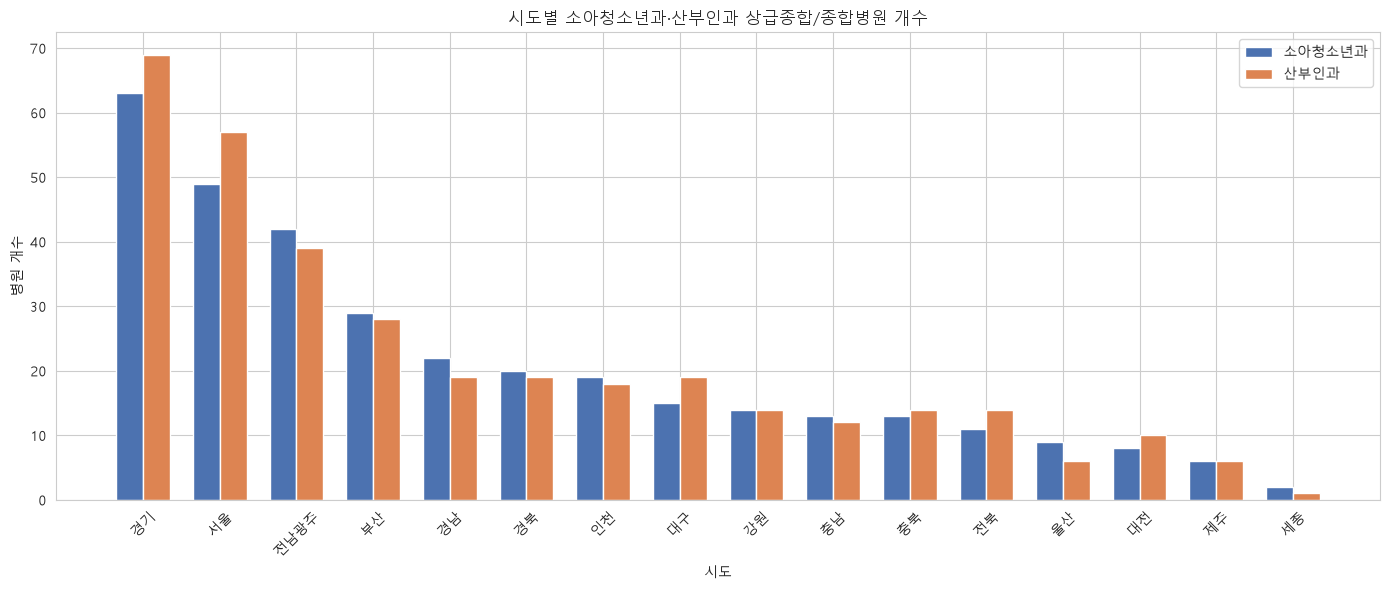

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

# 시도별 병원 개수 단순 비교
plt.rcParams['font.family'] = 'Malgun Gothic'  # 한글 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

# 병원 개수 많은 순으로 정렬 (보기 편하게)
final_sorted = final.sort_values('소아청소년과_개수', ascending=False)

fig, ax = plt.subplots(figsize=(14, 6))
x = range(len(final_sorted))
width = 0.35

ax.bar([i - width/2 for i in x], final_sorted['소아청소년과_개수'], width, label='소아청소년과', color='#4C72B0')
ax.bar([i + width/2 for i in x], final_sorted['산부인과_개수'], width, label='산부인과', color='#DD8452')

ax.set_xticks(x)
ax.set_xticklabels(final_sorted['hs_시도명_clean'], rotation=45)
ax.set_xlabel('시도')
ax.set_ylabel('병원 개수')
ax.set_title('시도별 소아청소년과·산부인과 상급종합/종합병원 개수')
ax.legend()

plt.tight_layout()
plt.show()

- 경기(소아청소년과 63개·산부인과 69개)가 가장 많고 세종(소아청소년과 2개·산부인과 1개)이 가장 적어, 지역 간 최대 약 31~69배에 달하는 큰 차이를 보인다. 서울(49개·57개), 전남광주(42개·39개)가 뒤를 이어 상위권을 형성하며, 상위 3개 지역(경기·서울·전남광주)이 나머지 지역과 뚜렷한 격차를 보인다. 다만 이는 두 지역의 인구 규모 차이 때문일 가능성이 있어, 인구 대비로 재확인이 필요하다.

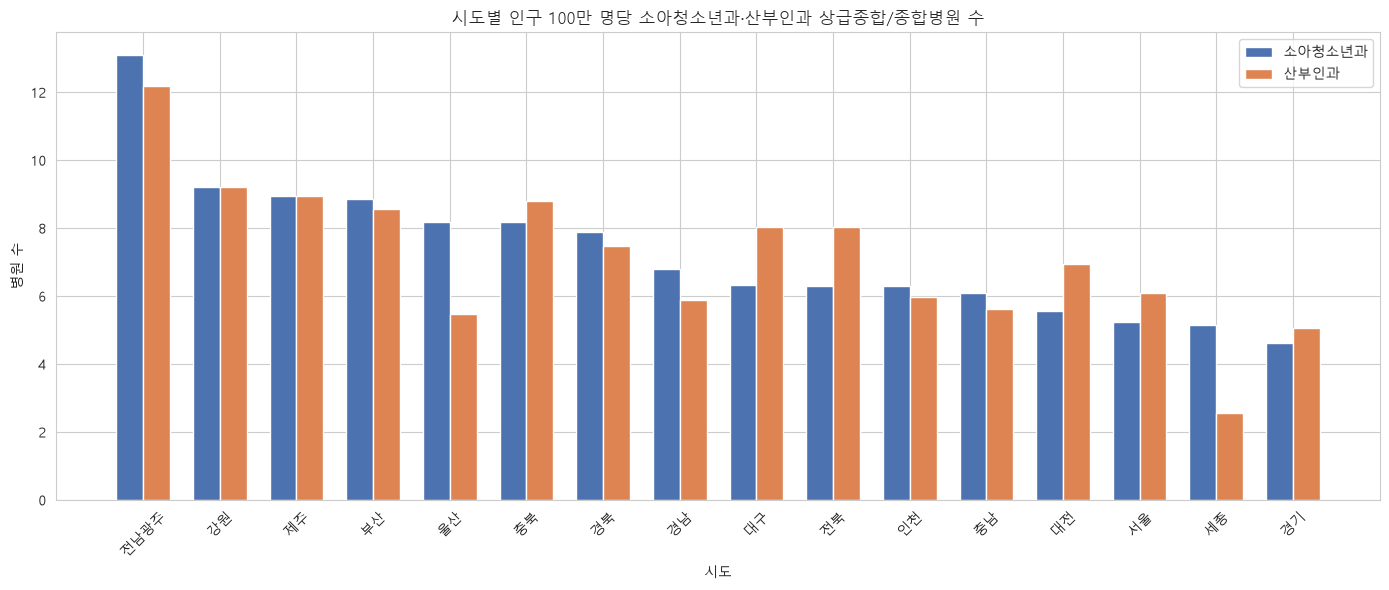

In [ ]:
# 인구 10만 명당 병원 수
final_sorted2 = final.sort_values('소아청소년과_100만명당', ascending=False)

fig, ax = plt.subplots(figsize=(14, 6))
x = range(len(final_sorted2))
width = 0.35

ax.bar([i - width/2 for i in x], final_sorted2['소아청소년과_100만명당'], width, label='소아청소년과', color='#4C72B0')
ax.bar([i + width/2 for i in x], final_sorted2['산부인과_100만명당'], width, label='산부인과', color='#DD8452')

ax.set_xticks(x)
ax.set_xticklabels(final_sorted2['hs_시도명_clean'], rotation=45)
ax.set_xlabel('시도')
ax.set_ylabel('병원 개수')
ax.set_title('시도별 인구 100만 명당 소아청소년과·산부인과 상급종합/종합병원 수')
ax.legend()

plt.tight_layout()
plt.show()


- 인구 대비로 재계산하니 단순 개수 기준과는 정반대되는 순위가 나타났다. 전남광주(합산 권역)가 소아청소년과 13.1개·산부인과 12.2개로 압도적 1위를 차지했고, 강원·제주·부산도 인구 대비로는 상위권에 속했다. 반면 단순 개수로는 상위권이었던 서울과 경기는 오히려 최하위권으로 밀려났다(서울 5.2개·6.1개, 경기 4.6개·5.0개). 이는 서울·경기가 절대 병원 개수는 많지만 그만큼 인구도 많아, 인구 대비로는 상급 의료기관 집중도가 오히려 낮다는 것을 보여준다. 세종은 산부인과 기준으로 가장 낮은 수치(2.5개)를 보여, 인구 대비로도 여전히 취약한 지역으로 나타났다.

ERROR: Invalid requirement: '#': Expected package name at the start of dependency specifier
    #
    ^


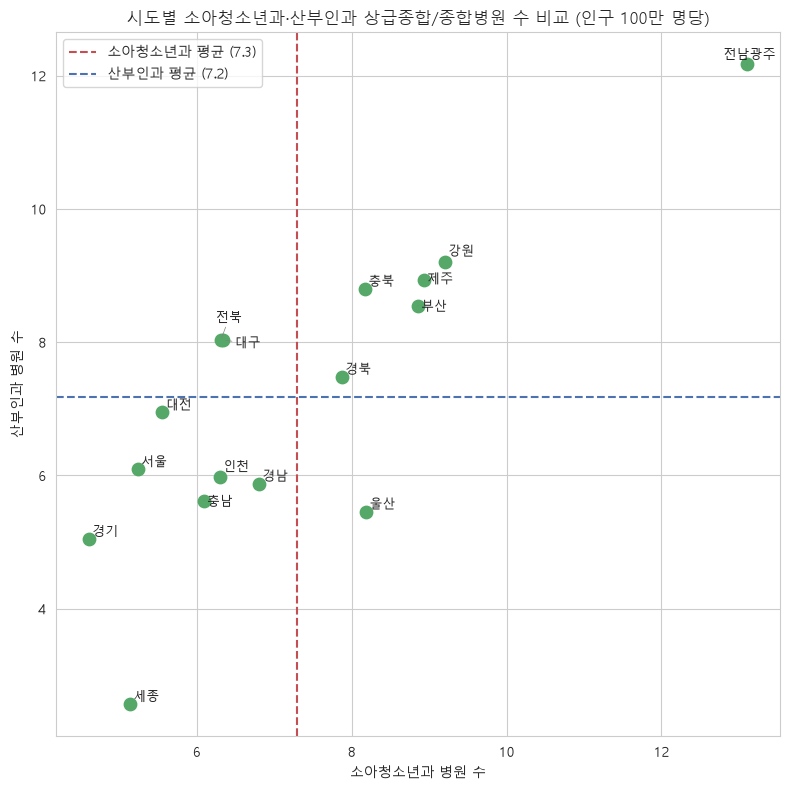

In [ ]:
# 소아청소년과 vs 산부인과 패턴 비교 산점도
!pip install adjustText # 글씨 겹치지 않게

from adjustText import adjust_text

fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(final['소아청소년과_100만명당'], final['산부인과_100만명당'], s=80, color='#55A868')

texts = []
for i, row in final.iterrows():
    texts.append(ax.text(row['소아청소년과_100만명당'], row['산부인과_100만명당'], row['hs_시도명_clean'], fontsize=9))

adjust_text(texts, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))

child_mean = final['소아청소년과_100만명당'].mean()
ob_mean = final['산부인과_100만명당'].mean()

ax.axvline(child_mean, color='#C44E52', linestyle='--', linewidth=1.5, label=f'소아청소년과 평균 ({child_mean:.1f})')
ax.axhline(ob_mean, color='#4C72B0', linestyle='--', linewidth=1.5, label=f'산부인과 평균 ({ob_mean:.1f})')

ax.set_xlabel('소아청소년과 병원 수')
ax.set_ylabel('산부인과 병원 수')
ax.set_title('시도별 소아청소년과·산부인과 상급종합/종합병원 수 비교 (인구 100만 명당)')
ax.legend()

plt.tight_layout()
plt.show()

- 평균(소아청소년과 7.3, 산부인과 7.2) 기준으로 보면, 전남광주·강원·제주·부산·충북·경북은 두 진료과목 모두 평균 이상인 반면, 서울·경기·인천·충남·경남·울산·세종은 두 진료과목 모두 평균 이하로 나타나 지역이 뚜렷하게 두 그룹으로 갈리는 모습을 보인다. 특히 전북·대구는 소아청소년과는 평균 이하이지만 산부인과는 평균 이상으로, 두 진료과목 간 균형이 지역마다 다르게 나타날 수 있음을 보여준다. 세종은 두 진료과목 모두 최하위권으로, 상급 의료기관 접근성이 가장 취약한 지역으로 확인된다.